# Distributed KalmanNet Training

This notebook trains `GraphKalmanProcess` on the distance/angle tracking task, saves one model per measurement noise level, and evaluates the trained models on fresh simulations.

In [ ]:
import importlib
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
from pytorch_lightning.loggers import CSVLogger
from torch_geometric.loader import DataLoader
from tqdm import tqdm

torch.set_default_dtype(torch.float32)

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.DistributedKalmanData import GraphDataset
from utils.DistributedKalmanNet import GraphKalmanProcess
from utils.ConstantVelocityScenario import ConstantVelocityModel, DistanceAngleObservation, create_distance_based_graph

In [12]:
def seed_everything(seed=42):
    """Set random seeds for reproducible experiments."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True


def get_trainer_accelerator():
    if torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "gpu"
    return "cpu"

## Simulation Setup

Define the sensor layout, state dimension, and the constant-velocity dynamics used for training and evaluation.

In [ ]:
seed_everything(42)

# Problem dimensions
num_nodes = 10
state_dimension = 4
TIME_STEPS = 20
test_time_steps = 20
time_delta = 0.1

# Noise and initialization
R_SCALE = np.array([0.25, 0.5, 0.75, 1.0])
scale = 1
q = 1

# Generate one sensor layout and reuse it for both training and evaluation.
node_positions = np.random.rand(num_nodes, 2) * 100
h_sys_linear = DistanceAngleObservation(node_positions)
f_sys_linear = ConstantVelocityModel(time_delta)
g = create_distance_based_graph(node_positions, 5)

print("Node positions:")
print(node_positions)
print(f"Trainer accelerator: {get_trainer_accelerator()}")

Node positions:
[[37.45401188 95.07143064]
 [73.19939418 59.86584842]
 [15.60186404 15.59945203]
 [ 5.80836122 86.61761458]
 [60.11150117 70.80725778]
 [ 2.05844943 96.99098522]
 [83.24426408 21.23391107]
 [18.18249672 18.34045099]
 [30.4242243  52.47564316]
 [43.19450186 29.12291402]]
Trainer accelerator: mps


In [14]:
def plot_learning_curve(log_dir, r_value, save_dir):
    """Plot epoch-level training and validation loss from Lightning logs."""
    metrics_path = os.path.join(log_dir, "metrics.csv")
    df = pd.read_csv(metrics_path)

    plt.figure(figsize=(7, 5))
    plotted = False

    if "train_loss:_epoch" in df.columns:
        train_df = df.dropna(subset=["train_loss:_epoch"])
        plt.plot(train_df["epoch"], train_df["train_loss:_epoch"], marker="o", label="Train Loss")
        plotted = True

    if "val_loss:_epoch" in df.columns:
        val_df = df.dropna(subset=["val_loss:_epoch"])
        plt.plot(val_df["epoch"], val_df["val_loss:_epoch"], marker="o", label="Val Loss")
        plotted = True

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss per Epoch (r = {r_value})")
    plt.grid(True)
    if plotted:
        plt.legend()

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"learning_curve_r={r_value}.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved learning curve: {save_path}")

Training node positions:
[[37.45401188 95.07143064]
 [73.19939418 59.86584842]
 [15.60186404 15.59945203]
 [ 5.80836122 86.61761458]
 [60.11150117 70.80725778]
 [ 2.05844943 96.99098522]
 [83.24426408 21.23391107]
 [18.18249672 18.34045099]
 [30.4242243  52.47564316]
 [43.19450186 29.12291402]]

Training model for measurement noise r = 0.25


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory /Users/inega/Python/kalmanet2/distributedKNET/kfirlogs/kalman_no_consensus_r=0.25/0_kfir exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | gkf  | GraphKalmanFilter | 70.4 K | train
1 | loss | MSELoss           | 0      | train
---------------------------------------------------
70.4 K    Trainable params
0         Non-trainable params
70.4 K    Total params
0.282     Total estimated model params size (MB)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss:_epoch did not improve in the last 5 records. Best score: 4.645. Signaling Trainer to stop.


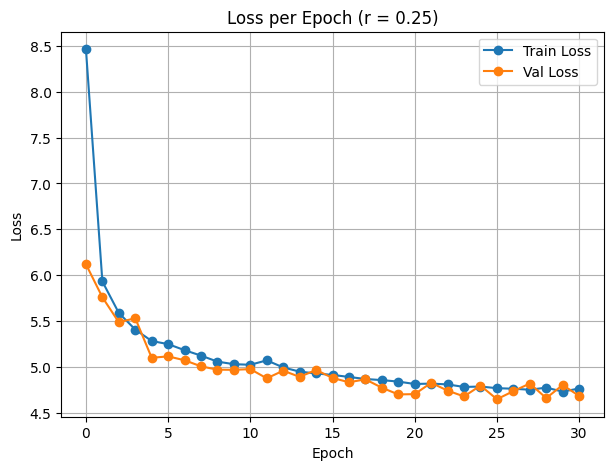

Saved learning curve: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/learning_curve_r=0.25.png
Saved model: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/DKN/const_vel_scenario_r=0.25.pth

Training model for measurement noise r = 0.5


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory /Users/inega/Python/kalmanet2/distributedKNET/kfirlogs/kalman_no_consensus_r=0.5/0_kfir exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/inega/Python/kalmanet2/distributedKNET/kfirlogs/kalman_no_consensus_r=0.5/0_kfir/checkpoints exists and is not empty.

  | Name | Type              | Params | Mode 
-----------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss:_epoch did not improve in the last 5 records. Best score: 4.759. Signaling Trainer to stop.


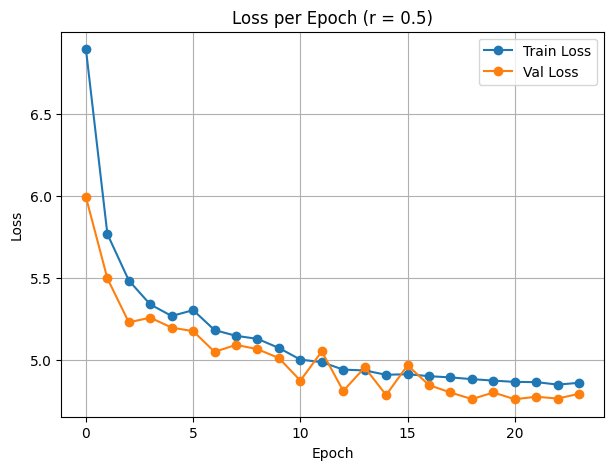

Saved learning curve: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/learning_curve_r=0.5.png
Saved model: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/DKN/const_vel_scenario_r=0.5.pth

Training model for measurement noise r = 0.75


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | gkf  | GraphKalmanFilter | 70.4 K | train
1 | loss | MSELoss           | 0      | train
---------------------------------------------------
70.4 K    Trainable params
0         Non-trainable params
70.4 K    Total params
0.282     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss:_epoch did not improve in the last 5 records. Best score: 4.840. Signaling Trainer to stop.


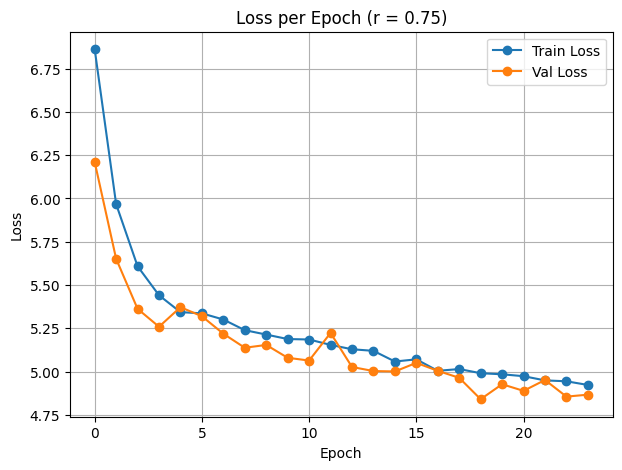

Saved learning curve: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/learning_curve_r=0.75.png
Saved model: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/DKN/const_vel_scenario_r=0.75.pth

Training model for measurement noise r = 1.0


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | gkf  | GraphKalmanFilter | 70.4 K | train
1 | loss | MSELoss           | 0      | train
---------------------------------------------------
70.4 K    Trainable params
0         Non-trainable params
70.4 K    Total params
0.282     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss:_epoch did not improve in the last 5 records. Best score: 4.868. Signaling Trainer to stop.


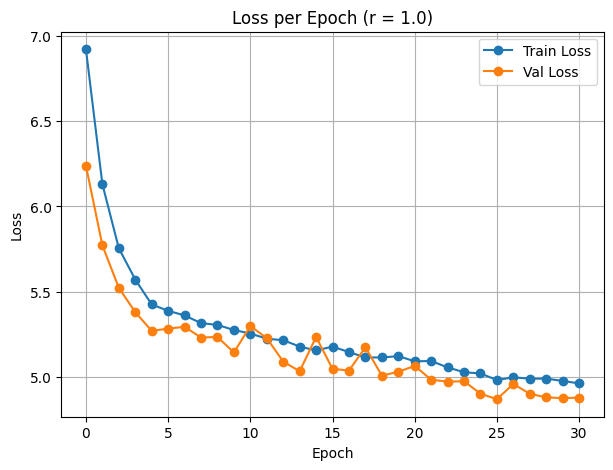

Saved learning curve: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/learning_curve_r=1.0.png
Saved model: /Users/inega/Python/kalmanet2/distributedKNET/models/const_vel_scenario/DKN/const_vel_scenario_r=1.0.pth


In [15]:
# Reload local modules so notebook runs use the latest edited Python files.
import utils.ConstantVelocityScenario as constant_velocity_scenario_module
import utils.DistributedKalmanNet as distributed_kalman_net_module

importlib.reload(constant_velocity_scenario_module)
importlib.reload(distributed_kalman_net_module)

from utils.ConstantVelocityScenario import ConstantVelocityModel, DistanceAngleObservation, create_distance_based_graph
from utils.DistributedKalmanNet import GraphKalmanProcess

seed_everything(42)

BATCH_SIZE = 64
TRAIN_SIMS = 10_000
VAL_SIMS = 256
MAX_EPOCHS = 40
accelerator = get_trainer_accelerator()
model_dir = REPO_ROOT / "models" / "const_vel_scenario" / "DKN"
plot_dir = REPO_ROOT / "models" / "const_vel_scenario"
model_dir.mkdir(parents=True, exist_ok=True)

# Recreate the system objects after reload so the notebook uses the updated classes.
h_sys_linear = DistanceAngleObservation(node_positions)
f_sys_linear = ConstantVelocityModel(time_delta)
g = create_distance_based_graph(node_positions, 5)

print("Training node positions:")
print(node_positions)

for r in R_SCALE:
    print(f"\nTraining model for measurement noise r = {r}")
    r_array = r * np.ones(num_nodes)

    train_dataset = GraphDataset(
        g, f_sys_linear, h_sys_linear, q, r_array,
        monte_carlo_simulations=TRAIN_SIMS,
        time_steps=TIME_STEPS,
        n_expansions=1,
        x0=scale,
        state_dim=state_dimension,
    )
    val_dataset = GraphDataset(
        g, f_sys_linear, h_sys_linear, q, r_array,
        monte_carlo_simulations=VAL_SIMS,
        time_steps=TIME_STEPS,
        n_expansions=1,
        x0=scale,
        state_dim=state_dimension,
    )

    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_dataset, shuffle=False, batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)

    kalman_process = GraphKalmanProcess(
        f_sys_linear,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=64,
        lr=1e-3,
        r_array=r,
        learn_edge_kalman=False,
        x0_scale=scale,
    ).to(torch.float32)

    early_stopping = pl.callbacks.EarlyStopping(
        monitor="val_loss:_epoch",
        patience=5,
        verbose=True,
        mode="min",
        min_delta=0.001,
    )
    logger = CSVLogger(str(REPO_ROOT / "kfirlogs"), name=f"kalman_no_consensus_r={r}", version="0_kfir")
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator=accelerator,
        devices=1,
        logger=logger,
        log_every_n_steps=5,
        callbacks=[early_stopping],
        gradient_clip_val=1,
    )

    trainer.fit(kalman_process, train_loader, val_loader)

    model_path = model_dir / f"const_vel_scenario_r={r}.pth"
    torch.save(kalman_process.state_dict(), model_path)
    plot_learning_curve(logger.log_dir, r, save_dir=str(plot_dir))
    print(f"Saved model: {model_path}")

In [16]:
# Build a fresh evaluation setup using the same sensor geometry.
node_num_test = num_nodes

print("Evaluation node positions:")
print(node_positions)

h_sys_test = DistanceAngleObservation(node_positions)
f_sys_test = ConstantVelocityModel(time_delta)

Evaluation node positions:
[[37.45401188 95.07143064]
 [73.19939418 59.86584842]
 [15.60186404 15.59945203]
 [ 5.80836122 86.61761458]
 [60.11150117 70.80725778]
 [ 2.05844943 96.99098522]
 [83.24426408 21.23391107]
 [18.18249672 18.34045099]
 [30.4242243  52.47564316]
 [43.19450186 29.12291402]]


In [ ]:
# Evaluate one saved model per noise level on fresh Monte Carlo simulations.
all_err_deep_kalman = []
model_dir = REPO_ROOT / "models" / "const_vel_scenario" / "DKN"

for r in R_SCALE:
    model_path = model_dir / f"const_vel_scenario_r={r}.pth"
    kalman_process = GraphKalmanProcess(
        f_sys_test,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=64,
        lr=1e-5,
        r_array=r,
        learn_edge_kalman=False,
        x0_scale=scale,
    )
    kalman_process.load_state_dict(torch.load(model_path, map_location="cpu"))
    kalman_process.eval()

    test_dataset = GraphDataset(
        g,
        f_sys_test,
        h_sys_test,
        q,
        r * np.ones(node_num_test),
        monte_carlo_simulations=100,
        time_steps=test_time_steps,
        n_expansions=1,
        x0=scale,
        state_dim=state_dimension,
    )

    x_pred_list = []
    x_true_list = []
    with torch.no_grad():
        for graph in tqdm(test_dataset, desc=f"Evaluating r={r}"):
            x_true = graph.y.squeeze().cpu().numpy()
            x_pred = kalman_process(graph).squeeze().cpu().numpy()

            # The model predicts one state per node, so average across nodes for a single trajectory estimate.
            x_true_list.append(x_true)
            x_pred_list.append(x_pred.mean(axis=1))

    x_pred_all = np.stack(x_pred_list, axis=0)
    x_true_all = np.stack(x_true_list, axis=0)
    mean_error = np.linalg.norm(x_true_all - x_pred_all, axis=-1).mean(axis=1).mean()
    all_err_deep_kalman.append(mean_error)

all_err_deep_kalman = np.asarray(all_err_deep_kalman)
print("Average evaluation error per noise level:")
for r, err in zip(R_SCALE, all_err_deep_kalman):
    print(f"r={r}: {err:.4f}")

Evaluating r=1.0: 100%|██████████| 100/100 [00:00<00:00, 134.06it/s]

Average evaluation error per noise level:
r=0.25: 4.0182
r=0.5: 4.1955
r=0.75: 4.2718
r=1.0: 4.2292
